# Data Processing and Visualization Notebook

This notebook loads both datasets in the workspace, performs basic cleaning, and creates visualizations such as:
- Histograms (scores, release years, runtimes)
- Evolution plots of release year vs average score
- Genre-based comparisons

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

In [36]:
# File paths
base = Path('./resources')
netflix_path = base / 'Netflix_TV_Shows_and_Movies.csv'
imdb_path = base / 'imdb_top_1000.csv'

# Load data
netflix = pd.read_csv(netflix_path)
imdb = pd.read_csv(imdb_path)

print('Netflix shape:', netflix.shape)
print('IMDb shape:', imdb.shape)

display(netflix.head(3))
display(imdb.head(3))

Netflix shape: (5283, 11)
IMDb shape: (1000, 15)


,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works as a night-time taxi driver in New York City where the perceived decad...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recruits his Knights of the Round Table, including Sir Bedevere the Wise, Si...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, but through a series of ridiculous events, he gains a reputation as the ...",1979,R,94,tt0079470,8.0,392419.0


,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the gre...",84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [37]:
# Helpers for cleaning
def to_numeric(series):
    return pd.to_numeric(series, errors='coerce')

def extract_runtime_minutes(series):
    # Works for values like '142 min'
    return to_numeric(series.astype(str).str.extract(r'(\d+)')[0])

def parse_gross(series):
    # Works for values like '28,341,469'
    return to_numeric(series.astype(str).str.replace(',', '', regex=False))

In [38]:
# Clean Netflix dataset
netflix_clean = netflix.copy()
netflix_clean['release_year'] = to_numeric(netflix_clean['release_year'])
netflix_clean['imdb_score'] = to_numeric(netflix_clean['imdb_score'])
netflix_clean['runtime'] = to_numeric(netflix_clean['runtime'])
netflix_clean['imdb_votes'] = to_numeric(netflix_clean['imdb_votes'])

# Clean IMDb Top 1000 dataset
imdb_clean = imdb.copy()
imdb_clean['Released_Year'] = to_numeric(imdb_clean['Released_Year'])
imdb_clean['IMDB_Rating'] = to_numeric(imdb_clean['IMDB_Rating'])
imdb_clean['Runtime_min'] = extract_runtime_minutes(imdb_clean['Runtime'])
imdb_clean['Meta_score'] = to_numeric(imdb_clean['Meta_score'])
imdb_clean['Gross_num'] = parse_gross(imdb_clean['Gross'])

# Keep first listed genre as a simpler category
imdb_clean['Main_Genre'] = imdb_clean['Genre'].astype(str).str.split(',').str[0].str.strip()

print('Missing values (Netflix):')
display(netflix_clean[['release_year', 'imdb_score', 'runtime', 'imdb_votes']].isna().sum())

print('Missing values (IMDb):')
display(imdb_clean[['Released_Year', 'IMDB_Rating', 'Runtime_min', 'Meta_score', 'Gross_num']].isna().sum())

Missing values (Netflix):


release_year     0
imdb_score       0
runtime          0
imdb_votes      16
dtype: int64

Missing values (IMDb):


Released_Year      1
IMDB_Rating        0
Runtime_min        0
Meta_score       157
Gross_num        169
dtype: int64

In [39]:
# Quick descriptive statistics
display(netflix_clean[['release_year', 'imdb_score', 'runtime', 'imdb_votes']].describe())
display(imdb_clean[['Released_Year', 'IMDB_Rating', 'Runtime_min', 'Meta_score', 'Gross_num']].describe())

,release_year,imdb_score,runtime,imdb_votes
count,5283.000000,5283.000000,5283.000000,5.267000e+03
mean,2015.879992,6.533447,79.199886,2.340719e+04
std,7.346098,1.160932,38.915974,8.713432e+04
min,1953.000000,1.500000,0.000000,5.000000e+00
25%,2015.000000,5.800000,45.000000,5.210000e+02
50%,2018.000000,6.600000,87.000000,2.279000e+03
75%,2020.000000,7.400000,106.000000,1.014400e+04
max,2022.000000,9.600000,235.000000,2.268288e+06


,Released_Year,IMDB_Rating,Runtime_min,Meta_score,Gross_num
count,999.000000,1000.000000,1000.000000,843.000000,8.310000e+02
mean,1991.217217,7.949300,122.891000,77.971530,6.803475e+07
std,23.297025,0.275491,28.093671,12.376099,1.097500e+08
min,1920.000000,7.600000,45.000000,28.000000,1.305000e+03
25%,1976.000000,7.700000,103.000000,70.000000,3.253559e+06
50%,1999.000000,7.900000,119.000000,79.000000,2.353089e+07
75%,2009.000000,8.100000,137.000000,87.000000,8.075089e+07
max,2020.000000,9.300000,321.000000,100.000000,9.366622e+08


## Histograms
Score, release year, and runtime distributions.

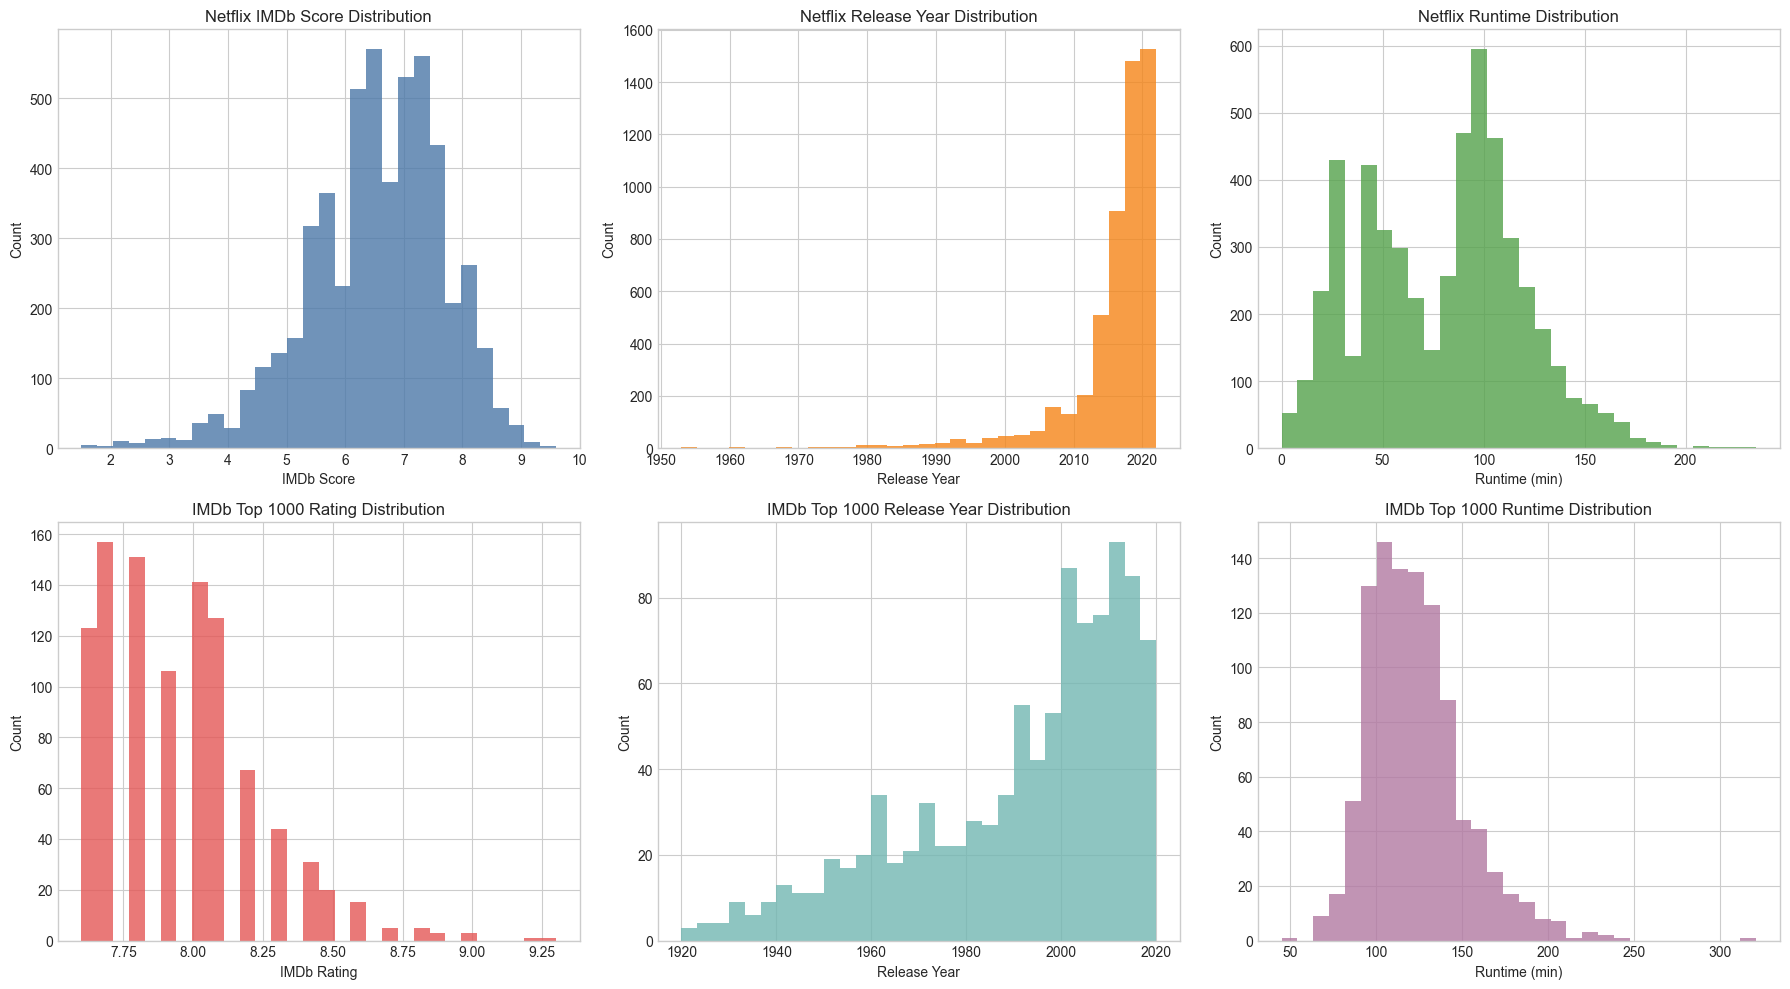

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Netflix
axes[0, 0].hist(netflix_clean['imdb_score'].dropna(), bins=30, color='#4C78A8', alpha=0.8)
axes[0, 0].set_title('Netflix IMDb Score Distribution')
axes[0, 0].set_xlabel('IMDb Score')

axes[0, 1].hist(netflix_clean['release_year'].dropna(), bins=30, color='#F58518', alpha=0.8)
axes[0, 1].set_title('Netflix Release Year Distribution')
axes[0, 1].set_xlabel('Release Year')

axes[0, 2].hist(netflix_clean['runtime'].dropna(), bins=30, color='#54A24B', alpha=0.8)
axes[0, 2].set_title('Netflix Runtime Distribution')
axes[0, 2].set_xlabel('Runtime (min)')

# IMDb Top 1000
axes[1, 0].hist(imdb_clean['IMDB_Rating'].dropna(), bins=30, color='#E45756', alpha=0.8)
axes[1, 0].set_title('IMDb Top 1000 Rating Distribution')
axes[1, 0].set_xlabel('IMDb Rating')

axes[1, 1].hist(imdb_clean['Released_Year'].dropna(), bins=30, color='#72B7B2', alpha=0.8)
axes[1, 1].set_title('IMDb Top 1000 Release Year Distribution')
axes[1, 1].set_xlabel('Release Year')

axes[1, 2].hist(imdb_clean['Runtime_min'].dropna(), bins=30, color='#B279A2', alpha=0.8)
axes[1, 2].set_title('IMDb Top 1000 Runtime Distribution')
axes[1, 2].set_xlabel('Runtime (min)')

for ax in axes.flat:
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Evolution: Release Year vs Average Score
Trend of average score by release year for each dataset.

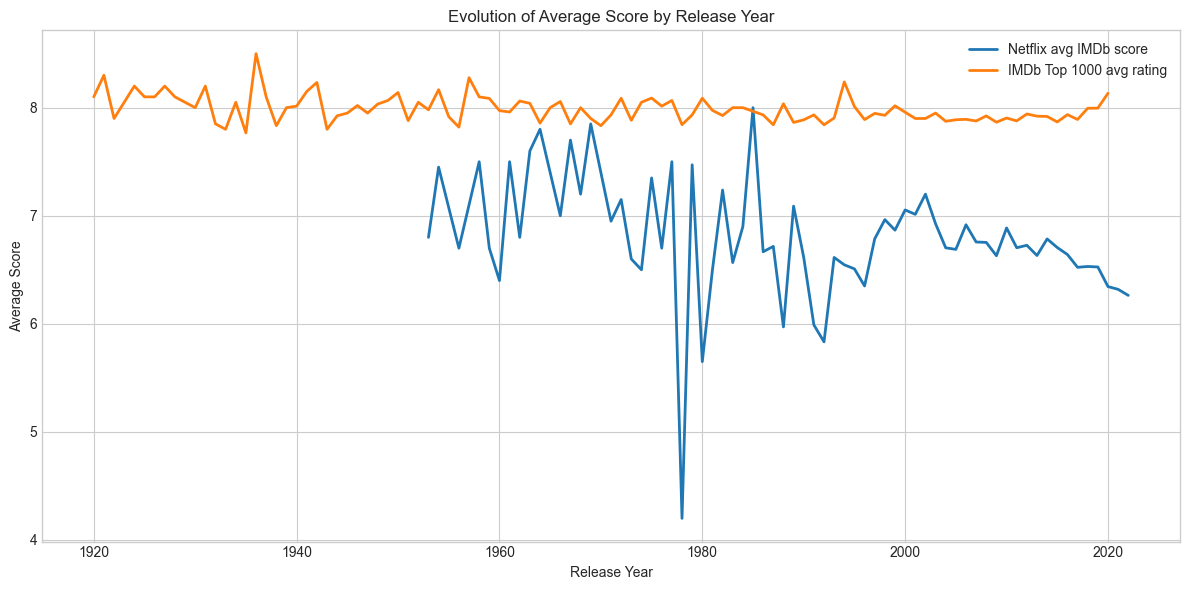

In [41]:
netflix_year_score = (
    netflix_clean.dropna(subset=['release_year', 'imdb_score'])
    .groupby('release_year', as_index=False)['imdb_score']
    .mean()
    .sort_values('release_year')
)

imdb_year_score = (
    imdb_clean.dropna(subset=['Released_Year', 'IMDB_Rating'])
    .groupby('Released_Year', as_index=False)['IMDB_Rating']
    .mean()
    .sort_values('Released_Year')
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(netflix_year_score['release_year'], netflix_year_score['imdb_score'], label='Netflix avg IMDb score', linewidth=2)
ax.plot(imdb_year_score['Released_Year'], imdb_year_score['IMDB_Rating'], label='IMDb Top 1000 avg rating', linewidth=2)

ax.set_title('Evolution of Average Score by Release Year')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Score')
ax.legend()
plt.tight_layout()
plt.show()

## Additional Feature Views
A few extra plots to compare score with other variables.

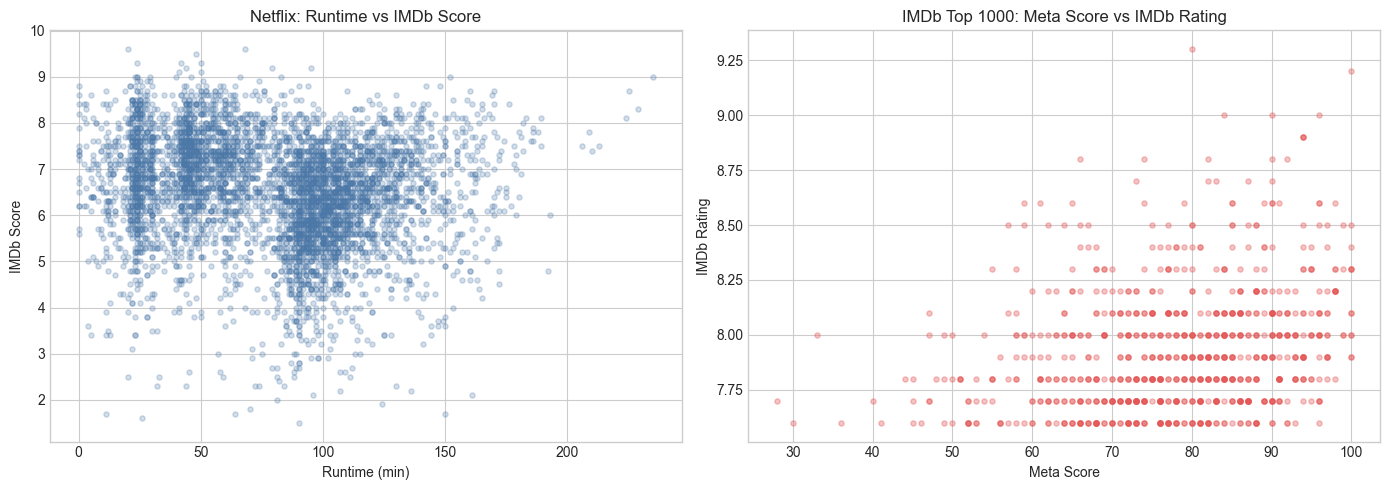

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Netflix: score vs runtime
netflix_scatter = netflix_clean.dropna(subset=['runtime', 'imdb_score'])
axes[0].scatter(netflix_scatter['runtime'], netflix_scatter['imdb_score'], alpha=0.25, s=14, color='#4C78A8')
axes[0].set_title('Netflix: Runtime vs IMDb Score')
axes[0].set_xlabel('Runtime (min)')
axes[0].set_ylabel('IMDb Score')

# IMDb Top 1000: score vs metascore
imdb_scatter = imdb_clean.dropna(subset=['IMDB_Rating', 'Meta_score'])
axes[1].scatter(imdb_scatter['Meta_score'], imdb_scatter['IMDB_Rating'], alpha=0.35, s=14, color='#E45756')
axes[1].set_title('IMDb Top 1000: Meta Score vs IMDb Rating')
axes[1].set_xlabel('Meta Score')
axes[1].set_ylabel('IMDb Rating')

plt.tight_layout()
plt.show()

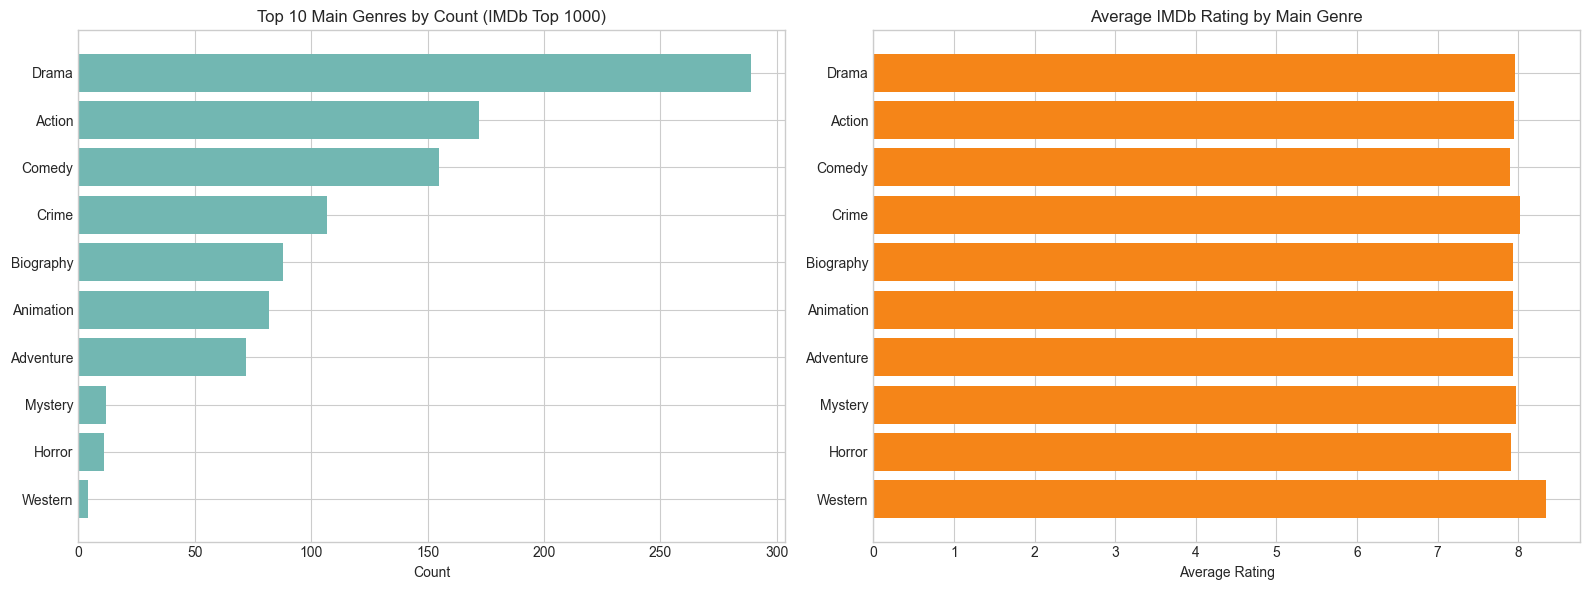

In [43]:
# Top genres in IMDb Top 1000
genre_counts = imdb_clean['Main_Genre'].value_counts().head(10).sort_values()
genre_mean_score = (
    imdb_clean[imdb_clean['Main_Genre'].isin(genre_counts.index)]
    .groupby('Main_Genre')['IMDB_Rating']
    .mean()
    .reindex(genre_counts.index)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(genre_counts.index, genre_counts.values, color='#72B7B2')
axes[0].set_title('Top 10 Main Genres by Count (IMDb Top 1000)')
axes[0].set_xlabel('Count')

axes[1].barh(genre_mean_score.index, genre_mean_score.values, color='#F58518')
axes[1].set_title('Average IMDb Rating by Main Genre')
axes[1].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()

##  Save cleaned outputs
Uncomment the next cell if you want to export cleaned datasets.

In [44]:
netflix_clean.to_csv('netflix_cleaned.csv', index=False)
imdb_clean.to_csv('imdb_top_1000_cleaned.csv', index=False)
print('Cleaned files saved.')

Cleaned files saved.
